In [ ]:
# use holodeck environment

In [ ]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [2]:
import holodeck as holo
import holodeck
from holodeck.constants import YR, NWTG, SPLC, GYR, PC, MSOL
from holodeck.galaxy_profiles import NFW
from holodeck import utils
from holodeck.librarian import DEF_NUM_FBINS, DEF_NUM_LOUDEST, DEF_PTA_DUR
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp, quad
import numpy as np
import kalepy as kale
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import os
import la_forge.core as co
from ceffyl.chain_utils import chain_utils
import la_forge.diagnostics as dg
from chainconsumer.chainconsumer import ChainConsumer
from emcee.autocorr import integrated_time

import numpy as np
import matplotlib.pyplot as plt

## for GPs

<class 'holodeck.librarian.param_spaces_classic.PS_Classic_SIDM_Astro_Extended_Version2'>
14:31:22 INFO : <holodeck.librarian.param_spaces_classic.PS_Classic_SIDM_Astro_Extended_Version2 object at 0x153969412d60>: nsamples=None nparameters=6 - cannot generate parameter samples. [lib_tools.py:__init__]
4000ing data from HDF5 file....
chain shape (123090, 15)
max log posterior value is: -12.716214
Max Likelihood Array For SIDM: -2.63, 11.03, 8.51, 0.38, 124.81, 127.86
14:31:26 INFO : Galaxy pair-fraction provided, using galaxy pair-fraction and merger-time. [sam.py:__init__]
14:34:30: starting calculating redz_final, diff_num
14:34:30 INFO : Adding MMbulge scatter (3.8479e-01) [sam.py:static_binary_density]
14:34:30 INFO : 	dens bef: (0.00e+00, 1.21e-272, 1.15e-44, 2.24e-05, 1.37e-03, 6.66e-03, 4.16e-02) [sam.py:static_binary_density]
14:35:00 INFO : Scatter added after 29.896734 sec [sam.py:static_binary_density]
14:35:00 INFO : 	dens aft: (2.39e-21, 6.16e-13, 7.23e-09, 9.02e-05, 2.36e-

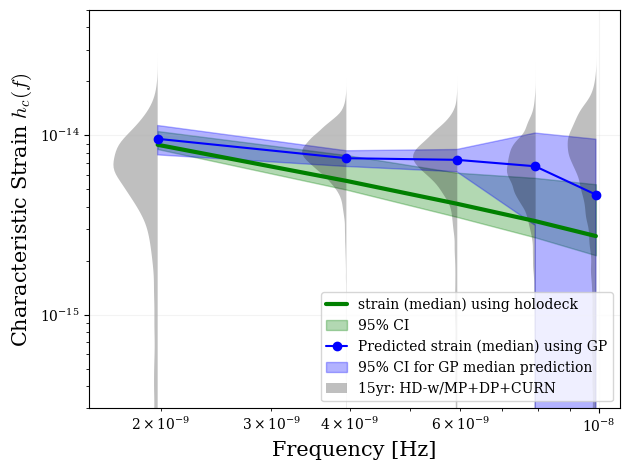

2000
chain shape (100000, 15)
max log posterior value is: -12.475784
Max Likelihood Array For SIDM: -2.73, 11.00, 8.72, 0.32, 91.69, 124.62
14:37:23 INFO : Galaxy pair-fraction provided, using galaxy pair-fraction and merger-time. [sam.py:__init__]
14:40:30: starting calculating redz_final, diff_num
14:40:30 INFO : Adding MMbulge scatter (3.1831e-01) [sam.py:static_binary_density]
14:40:31 INFO : 	dens bef: (0.00e+00, 9.28e-190, 1.35e-32, 2.47e-05, 1.22e-03, 5.75e-03, 3.57e-02) [sam.py:static_binary_density]
14:41:00 INFO : Scatter added after 29.750858 sec [sam.py:static_binary_density]
14:41:00 INFO : 	dens aft: (7.57e-24, 1.54e-13, 3.15e-09, 6.52e-05, 1.83e-03, 7.05e-03, 2.69e-02) [sam.py:static_binary_density]
14:41:00 INFO : 	mass: 2.81e-02 ==> 2.97e-02 || change = 5.6549e-02 [sam.py:static_binary_density]
14:41:00 INFO : zeroing out 5.58e+05/7.44e+05 = 7.49e-01 bins stalled from GMT [sam.py:static_binary_density]
14:42:30: redz_final, diff_num done
14:42:30: starting number calcu

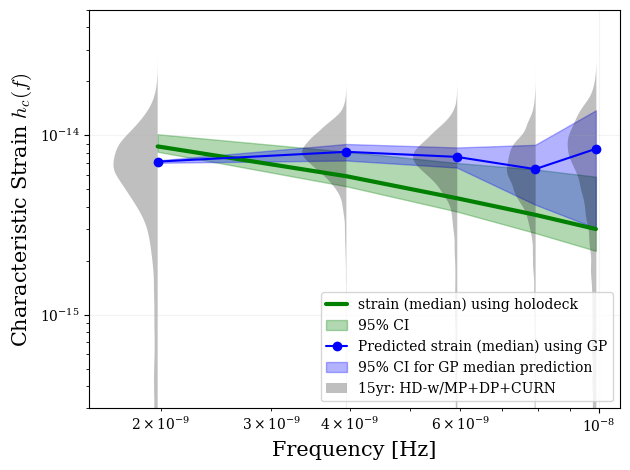

8000
chain shape (97400, 15)
max log posterior value is: -12.313637
Max Likelihood Array For SIDM: -2.57, 11.29, 8.43, 0.28, 96.86, 50.78
14:43:19 INFO : Galaxy pair-fraction provided, using galaxy pair-fraction and merger-time. [sam.py:__init__]
14:46:23: starting calculating redz_final, diff_num
14:46:23 INFO : Adding MMbulge scatter (2.7981e-01) [sam.py:static_binary_density]
14:46:23 INFO : 	dens bef: (0.00e+00, 1.80e-180, 4.36e-31, 4.13e-05, 1.87e-03, 8.50e-03, 5.27e-02) [sam.py:static_binary_density]
14:46:51 INFO : Scatter added after 28.374703 sec [sam.py:static_binary_density]
14:46:52 INFO : 	dens aft: (8.06e-27, 1.38e-14, 1.79e-09, 8.89e-05, 2.58e-03, 1.01e-02, 4.07e-02) [sam.py:static_binary_density]
14:46:52 INFO : 	mass: 4.19e-02 ==> 4.39e-02 || change = 4.5985e-02 [sam.py:static_binary_density]
14:46:52 INFO : zeroing out 5.58e+05/7.44e+05 = 7.50e-01 bins stalled from GMT [sam.py:static_binary_density]
14:48:22: redz_final, diff_num done
14:48:22: starting number calcula

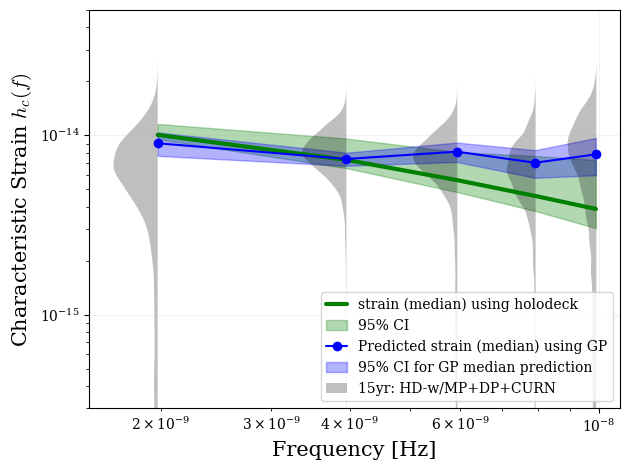

In [ ]:
nfreqs = 5
param_space = 'PS_Classic_SIDM_Astro_Extended_Version2'
space_name = param_space.split(".")
space_class = holo.librarian.param_spaces_dict[space_name[0]] # /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 498)
print(space_class)
# for edges
pta_dur = holo.librarian.DEF_PTA_DUR # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 363)
fobs_cents, fobs_edges = utils.pta_freqs(dur=pta_dur*YR, num=nfreqs) # from line 787 from /home/users/sti50/.conda/envs/holodeck_ceffyl_ptmcmc/lib/python3.9/site-packages/holodeck/librarian/lib_tools.py
fobs_orb_cents = fobs_cents / 2.0
fobs_orb_edges = fobs_edges / 2.0
space = space_class() # inspired from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py line 516
from holodeck.gps import gp_utils
import pickle, h5py, glob, os
from pathlib import Path
frequencies = fobs_cents  # shape: (n_freqs,)
from holodeck import plot, utils
# Load 15-year data
# insert your own path here
my_path = f'{PROJECT_ROOT}/Data/holodeck_astro_data_luke_kelly/' # added by me
chain_hdall = co.Core(corepath= my_path + 'freespec_posteriors/freespec_hd_all.core')
Tspan = DEF_PTA_DUR * YR

for n_train in [4000, 2000, 8000]:
    print(n_train)
    chain_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{n_train}_r2000_f5/gp_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'
    data = np.loadtxt(chain_path)
    print('chain shape', data.shape)
    maxLidx = np.argmax(data[:, -4]) # 4th to last column is log posterior
    print(f'max log posterior value is: {data[maxLidx, -4]}')
    maxL = data[maxLidx, :6] # last 4 columns in mcmc chains here are log posterior, and other stuff
    print("Max Likelihood Array For SIDM:", ", ".join("{:.2f}".format(ml) for ml in maxL))  # respects your .format preference
    maxL_param_values = maxL.tolist()
    param_names = ['gsmf_phi0_log10', 'gsmf_mchar0_log10', 'mmb_mamp_log10', 'mmb_scatter_dex', 'vt', 'sigma0_over_m_times_t_age_per_1Gyr']
    params_maxL = dict(zip(param_names, maxL_param_values))
    params = params_maxL
    sam, hard = space.model_for_params(params) # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 302)
    gwb_for_maxL_params = holo.librarian.lib_tools.run_model(
        sam, hard,
        pta_dur=DEF_PTA_DUR, nfreqs=nfreqs, nreals=2000, nloudest=DEF_NUM_LOUDEST,
        gwb_flag=True, singles_flag=False, details_flag=False, params_flag=False,
        log=None,
    )
    strain_realizations = gwb_for_maxL_params['gwb']  # shape: (n_freqs, n_samples)
    # Compute statistics
    strain_median = np.median(strain_realizations, axis=1)
    # two sigma
    strain_lower = np.percentile(strain_realizations, 2.5, axis=1)
    strain_upper = np.percentile(strain_realizations, 97.5, axis=1)
    print(f'for n_train={n_train}\n')
    print(f'strain_median = {strain_median}')
    print(f'strain_lower = {strain_lower}')
    print(f'strain_upper = {strain_upper}')
    # GP prediction
    test_array = maxL
    GW_var_gp_george_pkl = [Path(chain_path).parents[2] / 'gp_training_output/std.pkl']
    GW_gp_george_pkl = [Path(chain_path).parents[2] / 'gp_training_output/med.pkl']
    GW_gp_george = pickle.load(open(GW_gp_george_pkl[0], 'rb'))
    GW_var_gp_george = pickle.load(open(GW_var_gp_george_pkl[0], 'rb'))
    # make gaussprob objects
    spectra = None
    GW_gp = gp_utils.set_up_predictions(spectra, GW_gp_george)
    GW_var_gp = gp_utils.set_up_predictions(spectra, GW_var_gp_george)
    max_spec_sidm_gp, rho_gp, rho_pred_gp = gp_utils.hc_from_gp(GW_gp_george[:nfreqs], GW_gp[:nfreqs],
                                                    GW_var_gp_george[:nfreqs], GW_var_gp[:nfreqs],
                                                    #    maxL)
                                                    test_array)
    max_spec_sidm_std_gp = 0.5 * np.log(10) * max_spec_sidm_gp * rho_pred_gp[:, 1] # using chatGPT
    print(f'max_spec_sidm_gp = {max_spec_sidm_gp}')
    print(f'max_spec_sidm_std_gp = {max_spec_sidm_std_gp}')
    # plotting
    plt.loglog(frequencies[0:nfreqs], strain_median[0:nfreqs], color='green', lw=3, label='strain (median) using holodeck')
    plt.fill_between(frequencies[0:nfreqs], strain_lower[0:nfreqs], strain_upper[0:nfreqs], color='green', alpha=0.3, label='95% CI')
    # strain using GPs
    plt.loglog(fobs_cents[0:nfreqs], max_spec_sidm_gp, color='blue', marker='o', label='Predicted strain (median) using GP')
    plt.fill_between(fobs_cents[0:nfreqs], max_spec_sidm_gp - 2*max_spec_sidm_std_gp, max_spec_sidm_gp + 2*max_spec_sidm_std_gp, color='blue', alpha=0.3, label='95% CI for GP median prediction')
    for ii in range(5):
        if ii < 6:
            idx = np.where(chain_hdall(chain_hdall.params[(-64+ii)]) > -9)
            dd = chain_hdall(chain_hdall.params[(-64+ii)])[idx]
        else:
            dd = chain_hdall(chain_hdall.params[(-64+ii)])
        yy, zz = kale.density(dd, probability=True)
        hc = (np.sqrt((10**yy)**2 * (12*np.pi**2*frequencies[ii]**3*Tspan)))
        if ii == 0:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
                        side='left', color='k', median=False, line=None, label=r'15yr: HD-w/MP+DP+CURN')
        elif 0 < ii < 3:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
                        side='left', color='k', median=False, line=None)
        elif 2 < ii < 5:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.1, 
                        side='left', color='k', median=False, line=None)
    plt.xlabel("Frequency [Hz]", fontsize=15)
    plt.ylabel(r"Characteristic Strain $h_c(f)$", fontsize=15)
    # plt.xlim(1.5e-9, 3e-8)
    plt.ylim(3e-16, 5e-14)
    plt.legend(loc='lower right')
    # plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## for NNs

<class 'holodeck.librarian.param_spaces_classic.PS_Classic_SIDM_Astro_Extended_Version2'>
14:04:29 INFO : <holodeck.librarian.param_spaces_classic.PS_Classic_SIDM_Astro_Extended_Version2 object at 0x145f698fb940>: nsamples=None nparameters=6 - cannot generate parameter samples. [lib_tools.py:__init__]


2026-02-27 14:04:30.714632: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 14:04:31.808425: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-27 14:04:31.808718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-27 14:04:32.041075: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-27 14:04:32.451339: I tensorflow/core/platform/cpu_feature_guar

2000ing data from HDF5 file....
chain shape (130000, 15)
max log posterior value is: -14.348291
Max Likelihood Array For SIDM: -2.36, 11.10, 8.55, 0.31, 227.37, 23.63
14:04:43 INFO : Galaxy pair-fraction provided, using galaxy pair-fraction and merger-time. [sam.py:__init__]
14:07:37: starting calculating redz_final, diff_num
14:07:37 INFO : Adding MMbulge scatter (3.0845e-01) [sam.py:static_binary_density]
14:07:37 INFO : 	dens bef: (0.00e+00, 9.75e-210, 3.31e-35, 5.62e-05, 2.86e-03, 1.34e-02, 8.35e-02) [sam.py:static_binary_density]
14:08:10 INFO : Scatter added after 32.606212 sec [sam.py:static_binary_density]
14:08:10 INFO : 	dens aft: (4.69e-25, 7.32e-14, 4.10e-09, 1.43e-04, 4.20e-03, 1.64e-02, 6.35e-02) [sam.py:static_binary_density]
14:08:10 INFO : 	mass: 6.57e-02 ==> 6.92e-02 || change = 5.3910e-02 [sam.py:static_binary_density]
14:08:10 INFO : zeroing out 5.58e+05/7.44e+05 = 7.50e-01 bins stalled from GMT [sam.py:static_binary_density]
14:09:40: redz_final, diff_num done
14:0

2026-02-27 14:10:15.761196: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


max_spec_sidm_nn = [1.2790958e-14 7.9477771e-15 6.1498581e-15 5.0949167e-15 4.3850777e-15]
max_spec_sidm_std_nn = [8.52052644e-16 1.10286341e-15 1.10709641e-15 1.02521346e-15
 1.00500940e-15]


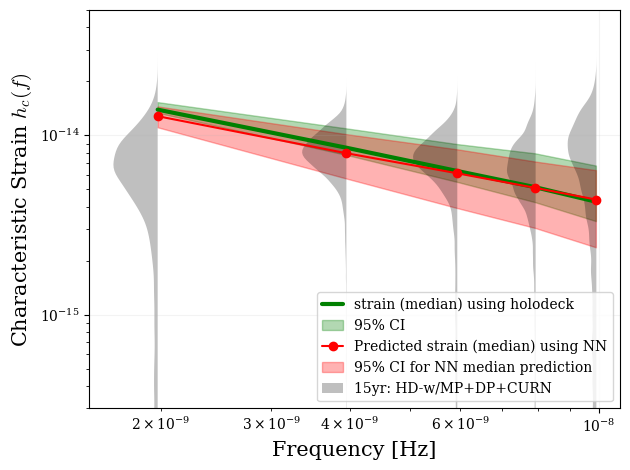

4000
chain shape (113900, 15)
max log posterior value is: -13.84472
Max Likelihood Array For SIDM: -2.42, 11.06, 8.58, 0.28, 222.38, 7.33
14:10:23 INFO : Galaxy pair-fraction provided, using galaxy pair-fraction and merger-time. [sam.py:__init__]
14:13:11: starting calculating redz_final, diff_num
14:13:11 INFO : Adding MMbulge scatter (2.7730e-01) [sam.py:static_binary_density]
14:13:11 INFO : 	dens bef: (0.00e+00, 1.71e-220, 7.89e-37, 4.55e-05, 2.41e-03, 1.14e-02, 7.12e-02) [sam.py:static_binary_density]
14:13:41 INFO : Scatter added after 30.201173 sec [sam.py:static_binary_density]
14:13:41 INFO : 	dens aft: (8.71e-29, 1.73e-15, 9.70e-10, 1.03e-04, 3.36e-03, 1.36e-02, 5.51e-02) [sam.py:static_binary_density]
14:13:41 INFO : 	mass: 5.58e-02 ==> 5.84e-02 || change = 4.6131e-02 [sam.py:static_binary_density]
14:13:41 INFO : zeroing out 5.58e+05/7.44e+05 = 7.50e-01 bins stalled from GMT [sam.py:static_binary_density]
14:15:12: redz_final, diff_num done
14:15:12: starting number calcula

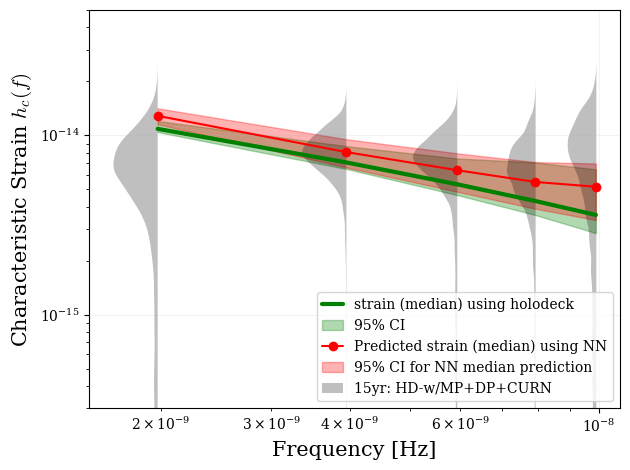

8000
chain shape (127744, 15)
max log posterior value is: -13.124399
Max Likelihood Array For SIDM: -2.16, 11.16, 8.56, 0.31, 62.88, 53.79
14:15:55 INFO : Galaxy pair-fraction provided, using galaxy pair-fraction and merger-time. [sam.py:__init__]
14:19:01: starting calculating redz_final, diff_num
14:19:01 INFO : Adding MMbulge scatter (3.0748e-01) [sam.py:static_binary_density]
14:19:01 INFO : 	dens bef: (0.00e+00, 2.47e-180, 1.02e-30, 1.02e-04, 4.72e-03, 2.18e-02, 1.35e-01) [sam.py:static_binary_density]
14:19:31 INFO : Scatter added after 30.230733 sec [sam.py:static_binary_density]
14:19:31 INFO : 	dens aft: (8.44e-24, 4.03e-13, 1.08e-08, 2.48e-04, 6.88e-03, 2.64e-02, 1.03e-01) [sam.py:static_binary_density]
14:19:31 INFO : 	mass: 1.07e-01 ==> 1.13e-01 || change = 5.3260e-02 [sam.py:static_binary_density]
14:19:31 INFO : zeroing out 5.58e+05/7.44e+05 = 7.50e-01 bins stalled from GMT [sam.py:static_binary_density]
14:21:02: redz_final, diff_num done
14:21:02: starting number calcul

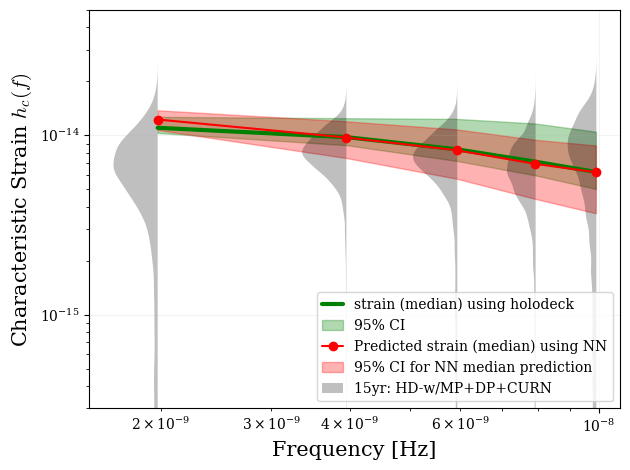

In [ ]:
nfreqs = 5
param_space = 'PS_Classic_SIDM_Astro_Extended_Version2'
space_name = param_space.split(".")
space_class = holo.librarian.param_spaces_dict[space_name[0]] # /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 498)
print(space_class)
# for edges
pta_dur = holo.librarian.DEF_PTA_DUR # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 363)
fobs_cents, fobs_edges = utils.pta_freqs(dur=pta_dur*YR, num=nfreqs) # from line 787 from /home/users/sti50/.conda/envs/holodeck_ceffyl_ptmcmc/lib/python3.9/site-packages/holodeck/librarian/lib_tools.py
fobs_orb_cents = fobs_cents / 2.0
fobs_orb_edges = fobs_edges / 2.0
space = space_class() # inspired from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py line 516
from pathlib import Path
from tensorflow import keras
import os
import tensorflow_probability as tfp
tfpl = tfp.layers
tfd = tfp.distributions
frequencies = fobs_cents  # shape: (n_freqs,)
from holodeck import plot, utils
# Load 15-year data
# insert your own path here
my_path = f'{PROJECT_ROOT}/Data/holodeck_astro_data_luke_kelly/' # added by me
chain_hdall = co.Core(corepath= my_path + 'freespec_posteriors/freespec_hd_all.core')
Tspan = DEF_PTA_DUR * YR

for n_train in [2000, 4000, 8000]:
    print(n_train)
    chain_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{n_train}_r2000_f5/nn_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'
    data = np.loadtxt(chain_path)
    print('chain shape', data.shape)
    maxLidx = np.argmax(data[:, -4]) # 4th to last column is log posterior
    print(f'max log posterior value is: {data[maxLidx, -4]}')
    maxL = data[maxLidx, :6] # last 4 columns in mcmc chains here are log posterior, and other stuff
    print("Max Likelihood Array For SIDM:", ", ".join("{:.2f}".format(ml) for ml in maxL))  # respects your .format preference
    maxL_param_values = maxL.tolist()
    param_names = ['gsmf_phi0_log10', 'gsmf_mchar0_log10', 'mmb_mamp_log10', 'mmb_scatter_dex', 'vt', 'sigma0_over_m_times_t_age_per_1Gyr']
    params_maxL = dict(zip(param_names, maxL_param_values))
    params = params_maxL
    sam, hard = space.model_for_params(params) # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 302)
    gwb_for_maxL_params = holo.librarian.lib_tools.run_model(
        sam, hard,
        pta_dur=DEF_PTA_DUR, nfreqs=nfreqs, nreals=2000, nloudest=DEF_NUM_LOUDEST,
        gwb_flag=True, singles_flag=False, details_flag=False, params_flag=False,
        log=None,
    )
    strain_realizations = gwb_for_maxL_params['gwb']  # shape: (n_freqs, n_samples)
    # Compute statistics
    strain_median = np.median(strain_realizations, axis=1)
    # two sigma
    strain_lower = np.percentile(strain_realizations, 2.5, axis=1)
    strain_upper = np.percentile(strain_realizations, 97.5, axis=1)
    print(f'for n_train={n_train}\n')
    print(f'strain_median = {strain_median}')
    print(f'strain_lower = {strain_lower}')
    print(f'strain_upper = {strain_upper}')
    # NN prediction
    etac = maxL
    nn_dir = Path(chain_path).parents[2] / 'nn_training_output'
    model_median = keras.models.load_model(os.path.join(nn_dir, "nn_model_median.keras"),
        custom_objects={"DistributionLambda": tfpl.DistributionLambda},
        compile=False,safe_mode=False)
    model_std = keras.models.load_model(os.path.join(nn_dir, "nn_model_std.keras"),
        custom_objects={"DistributionLambda": tfpl.DistributionLambda},
        compile=False,safe_mode=False)
    normalization_params = np.load(os.path.join(nn_dir, "normalization_params.npz"))
    mu_x = normalization_params["mu_x"]
    std_x = normalization_params["std_x"]
    mu_y_median = normalization_params["mu_y_median"]
    std_y_median = normalization_params["std_y_median"]
    std_y_std = normalization_params["std_y_std"]
    unnormalized_test_param = etac.reshape(1, len(etac)) # shape (1, 6)
    normalized_test_param = (unnormalized_test_param - mu_x) / std_x
    y_pred_dist_median = model_median(normalized_test_param)
    y_pred_median_nn = y_pred_dist_median.mean()
    y_pred_median_unc_nn = y_pred_dist_median.stddev()
    y_pred_dist_std = model_std(normalized_test_param)
    y_pred_std_nn = y_pred_dist_std.mean()
    y_pred_std_unc_nn = y_pred_dist_std.stddev()
    y_pred_total_std_nn = np.sqrt(y_pred_median_unc_nn**2 + y_pred_std_nn**2 + y_pred_std_unc_nn**2)
    y_pred_total_original_std_nn = y_pred_total_std_nn * std_y_std
    y_pred_original_median_nn = y_pred_median_nn * std_y_median + mu_y_median
    max_spec_sidm_nn = 10**(y_pred_original_median_nn.numpy().reshape(5,) / 2)
    rho_pred = y_pred_total_original_std_nn.reshape(5,)
    max_spec_sidm_std_nn = 0.5 * np.log(10) * max_spec_sidm_nn * rho_pred # using chatGPT
    print(f'max_spec_sidm_nn = {max_spec_sidm_nn}')
    print(f'max_spec_sidm_std_nn = {max_spec_sidm_std_nn}')
    # plotting
    plt.loglog(frequencies[0:nfreqs], strain_median[0:nfreqs], color='green', lw=3, label='strain (median) using holodeck')
    plt.fill_between(frequencies[0:nfreqs], strain_lower[0:nfreqs], strain_upper[0:nfreqs], color='green', alpha=0.3, label='95% CI')
    # strain using GPs
    plt.loglog(fobs_cents[0:nfreqs], max_spec_sidm_nn, color='red', marker='o', label='Predicted strain (median) using NN')
    plt.fill_between(fobs_cents[0:nfreqs], max_spec_sidm_nn - 2*max_spec_sidm_std_nn, max_spec_sidm_nn + 2*max_spec_sidm_std_nn, color='red', alpha=0.3, label='95% CI for NN median prediction')
    for ii in range(5):
        if ii < 6:
            idx = np.where(chain_hdall(chain_hdall.params[(-64+ii)]) > -9)
            dd = chain_hdall(chain_hdall.params[(-64+ii)])[idx]
        else:
            dd = chain_hdall(chain_hdall.params[(-64+ii)])
        yy, zz = kale.density(dd, probability=True)
        hc = (np.sqrt((10**yy)**2 * (12*np.pi**2*frequencies[ii]**3*Tspan)))
        if ii == 0:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
                        side='left', color='k', median=False, line=None, label=r'15yr: HD-w/MP+DP+CURN')
        elif 0 < ii < 3:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.15, 
                        side='left', color='k', median=False, line=None)
        elif 2 < ii < 5:
            plot.violin(plt.gca(), (frequencies[ii]), hc, zz, width=frequencies[ii]*0.1, 
                        side='left', color='k', median=False, line=None)
    plt.xlabel("Frequency [Hz]", fontsize=15)
    plt.ylabel(r"Characteristic Strain $h_c(f)$", fontsize=15)
    # plt.xlim(1.5e-9, 3e-8)
    plt.ylim(3e-16, 5e-14)
    plt.legend(loc='lower right')
    # plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()